# 72 - BLIP-2 画像キャプション生成

## 概要
専用の画像キャプション生成モデル BLIP-2 を導入し、画像から自然文のキャプションを生成する。
Notebook 71 の擬似キャプション（対照学習モデルによる近似）との比較を行い、
生成型モデルの優位性を定量的に確認する。

## BLIP-2 の特徴
- **Q-Former**: 画像エンコーダとLLMを橋渡しする学習可能なモジュール
- **Frozen ViT + LLM**: 事前学習済みの画像エンコーダ（ViT-G）とLLM（OPT-2.7B）を凍結して使用
- **軽量**: ~6GB VRAM で動作可能
- **制約**: 英語のみ（OPT バックボーン）

## 評価
- **Self-Retrieval Score**: キャプションembedding vs 画像embeddingのコサイン類似度
- **カテゴリ一貫性**: 同一カテゴリの画像に対するキャプションの意味的類似度
- **視覚的確認**: サンプル画像と生成キャプションの対応
- **Notebook 71 との比較**: 擬似キャプション vs 生成キャプション

## 使用モデル
- BLIP-2: `Salesforce/blip2-opt-2.7b`
- 評価用: SigLIP 2 Large (`google/siglip2-large-patch16-256`)

In [1]:
import json
import time
from datetime import datetime
from pathlib import Path

import duckdb
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
from PIL import Image
from tqdm.notebook import tqdm
from transformers import Blip2ForConditionalGeneration, Blip2Processor

## 1. 設定とデータ読み込み

In [2]:
DB_PATH = Path("../data/images.duckdb")
BLIP2_MODEL = "Salesforce/blip2-opt-2.7b"
SIGLIP2_MODEL = "google/siglip2-large-patch16-256"
BATCH_SIZE = 8

# 画像カタログの読み込み
conn = duckdb.connect(str(DB_PATH), read_only=True)

catalog_df = conn.execute("""
    SELECT id, file_path, category, file_name
    FROM image_catalog
    ORDER BY id
""").fetchdf()

# SigLIP 2 Large の画像埋め込みを読み込み（評価用）
embeddings_df = conn.execute("""
    SELECT c.id, e.embedding
    FROM image_catalog c
    JOIN image_embeddings e ON c.id = e.id
    WHERE e.model_name = ?
    ORDER BY c.id
""", [SIGLIP2_MODEL]).fetchdf()
conn.close()

image_embeddings = np.array(embeddings_df['embedding'].tolist(), dtype=np.float32)
norms = np.linalg.norm(image_embeddings, axis=1, keepdims=True)
image_embeddings_norm = image_embeddings / np.clip(norms, 1e-8, None)

print(f"Total images: {len(catalog_df)}")
print(f"Image embeddings: {image_embeddings.shape}")
print(f"\nCategories:")
for cat, count in catalog_df['category'].value_counts().items():
    print(f"  {cat}: {count}")

Total images: 378
Image embeddings: (378, 1024)

Categories:
  EuroPython2025: 129
  PyConJP2025: 77
  PyConJP2025-PreCampHiroshima: 57
  KashiwaVillagePark2026: 56
  TokyoNight202505: 49
  terada: 10


## 2. BLIP-2 モデルの読み込み

In [3]:
print(f"Loading BLIP-2 model: {BLIP2_MODEL}")
print("This may take a few minutes for the first download...")

processor = Blip2Processor.from_pretrained(BLIP2_MODEL)
model = Blip2ForConditionalGeneration.from_pretrained(
    BLIP2_MODEL,
    torch_dtype=torch.float16,
    device_map="auto",
)

print(f"Model loaded.")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

Loading BLIP-2 model: Salesforce/blip2-opt-2.7b
This may take a few minutes for the first download...


The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/1247 [00:00<?, ?it/s]

Model loaded.
GPU memory allocated: 7.2 GB


## 3. キャプション生成

3つのモードでキャプションを生成する:
1. **無条件**: プロンプトなしで自由にキャプション生成
2. **簡潔プロンプト**: "This photo shows" で始まるキャプション
3. **詳細プロンプト**: "Describe this image in detail:" で詳細なキャプション

In [4]:
def generate_caption(image: Image.Image, prompt: str | None = None,
                     max_new_tokens: int = 100) -> str:
    """BLIP-2でキャプションを生成する。"""
    if prompt:
        inputs = processor(images=image, text=prompt, return_tensors="pt").to(
            model.device, dtype=torch.float16
        )
    else:
        inputs = processor(images=image, return_tensors="pt").to(
            model.device, dtype=torch.float16
        )
    
    with torch.no_grad():
        generated_ids = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            num_beams=5,
            early_stopping=True,
        )
    
    caption = processor.batch_decode(generated_ids, skip_special_tokens=True)[0].strip()
    return caption

# テスト
test_img = Image.open(catalog_df.iloc[0]['file_path']).convert('RGB')
test_caption = generate_caption(test_img)
print(f"Test caption: {test_caption}")

Test caption: an asian man wearing a red polo shirt


In [5]:
# 全画像に対して3種類のキャプションを生成
prompts = {
    "unconditional": None,
    "brief": "This photo shows",
    "detailed": "Describe this image in detail:",
}

all_captions = {key: [] for key in prompts}

print(f"Generating captions for {len(catalog_df)} images x {len(prompts)} modes...")
start_time = time.time()

for idx in tqdm(range(len(catalog_df)), desc="Captioning"):
    row = catalog_df.iloc[idx]
    img = Image.open(row['file_path']).convert('RGB')
    
    for mode, prompt in prompts.items():
        caption = generate_caption(img, prompt=prompt)
        all_captions[mode].append(caption)

elapsed = time.time() - start_time
print(f"\nTotal time: {elapsed:.1f}s ({elapsed/len(catalog_df):.2f}s per image)")
print(f"Speed: {len(catalog_df) * len(prompts) / elapsed:.1f} captions/sec")

Generating captions for 378 images x 3 modes...


Captioning:   0%|          | 0/378 [00:00<?, ?it/s]


Total time: 433.5s (1.15s per image)
Speed: 2.6 captions/sec


In [6]:
# キャプションのサンプル表示
print("=" * 80)
print("Sample Captions")
print("=" * 80)

for cat in catalog_df['category'].unique():
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()[:2]
    print(f"\n--- {cat} ---")
    for idx in cat_indices:
        print(f"  [{catalog_df.iloc[idx]['file_name']}]")
        for mode in prompts:
            print(f"    {mode:15s}: {all_captions[mode][idx]}")
        print()

Sample Captions

--- terada ---
  [terada-202205-pyconjp-4-3-900.jpg]
    unconditional  : an asian man wearing a red polo shirt
    brief          : This photo shows a man wearing a red polo shirt
    detailed       : Describe this image in detail: a man in a red polo shirt

  [terada-uspycon2019-up.jpg]
    unconditional  : an asian man in a blue shirt standing at a podium
    brief          : This photo shows a man in a blue shirt standing at a podium
    detailed       : Describe this image in detail: a man in a blue shirt standing at a podium


--- PyConJP2025 ---
  [2025-09-27 18.17.03.jpg]
    unconditional  : a man standing in front of a projector screen
    brief          : This photo shows a man speaking in front of a large screen
    detailed       : Describe this image in detail:

  [2025-09-25 20.54.50.jpg]
    unconditional  : a crowd of people standing around a counter in a restaurant
    brief          : This photo shows a crowd of people in a restaurant
    detailed   

In [7]:
# キャプションの統計
print("=" * 60)
print("Caption Statistics")
print("=" * 60)

for mode in prompts:
    lengths = [len(c.split()) for c in all_captions[mode]]
    print(f"\n{mode}:")
    print(f"  Word count — Mean: {np.mean(lengths):.1f}, Std: {np.std(lengths):.1f}, "
          f"Min: {np.min(lengths)}, Max: {np.max(lengths)}")
    
    # ユニーク率
    unique_ratio = len(set(all_captions[mode])) / len(all_captions[mode])
    print(f"  Unique captions: {len(set(all_captions[mode]))} / {len(all_captions[mode])} ({unique_ratio*100:.1f}%)")

Caption Statistics

unconditional:
  Word count — Mean: 8.4, Std: 2.5, Min: 4, Max: 17
  Unique captions: 271 / 378 (71.7%)

brief:
  Word count — Mean: 10.8, Std: 1.6, Min: 5, Max: 18
  Unique captions: 240 / 378 (63.5%)

detailed:
  Word count — Mean: 7.3, Std: 3.7, Min: 5, Max: 23
  Unique captions: 113 / 378 (29.9%)


## 4. BLIP-2 のGPUメモリ解放 → SigLIP 2 で評価

In [8]:
# BLIP-2 モデルを解放
del model, processor
torch.cuda.empty_cache()
print("BLIP-2 model released.")
if torch.cuda.is_available():
    print(f"GPU memory allocated: {torch.cuda.memory_allocated() / 1024**3:.1f} GB")

BLIP-2 model released.
GPU memory allocated: 0.0 GB


In [9]:
# SigLIP 2 Large で生成キャプションをembed（評価用）
from image_vector_poc import SigLIP2Embedder

embedder = SigLIP2Embedder(model_name=SIGLIP2_MODEL, device="cuda")
print(f"Loaded: {embedder.model_name} (dim={embedder.embedding_dim})")

Loading weights:   0%|          | 0/792 [00:00<?, ?it/s]

The image processor of type `SiglipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Loaded: google/siglip2-large-patch16-256 (dim=1024)


## 5. Self-Retrieval Score の計算

In [10]:
# 各モードのキャプションをembed
caption_embeddings = {}

for mode in prompts:
    print(f"Embedding {mode} captions...")
    emb = embedder.embed_texts(all_captions[mode])
    caption_embeddings[mode] = emb
    print(f"  Shape: {emb.shape}")

print("Done.")

Embedding unconditional captions...


  Shape: (378, 1024)
Embedding brief captions...


  Shape: (378, 1024)
Embedding detailed captions...


  Shape: (378, 1024)
Done.


In [11]:
# Self-Retrieval Score の計算
self_retrieval = {}

print("=" * 60)
print("Self-Retrieval Score (BLIP-2 Captions)")
print("=" * 60)

for mode in prompts:
    scores = np.array([
        np.dot(image_embeddings_norm[i], caption_embeddings[mode][i])
        for i in range(len(catalog_df))
    ])
    self_retrieval[mode] = scores
    
    print(f"\n{mode}:")
    print(f"  Mean:  {scores.mean():.4f}")
    print(f"  Std:   {scores.std():.4f}")
    print(f"  Min:   {scores.min():.4f}")
    print(f"  Max:   {scores.max():.4f}")

Self-Retrieval Score (BLIP-2 Captions)

unconditional:
  Mean:  0.1426
  Std:   0.0364
  Min:   0.0225
  Max:   0.2846

brief:
  Mean:  0.1610
  Std:   0.0287
  Min:   0.0815
  Max:   0.2789

detailed:
  Mean:  0.0967
  Std:   0.0408
  Min:   0.0347
  Max:   0.2454


In [12]:
# カテゴリ別の Self-Retrieval Score
print("\n" + "=" * 80)
print("Self-Retrieval Score by Category")
print("=" * 80)

sr_df = pd.DataFrame({
    'category': catalog_df['category'],
    **{f'sr_{mode}': self_retrieval[mode] for mode in prompts}
})

cat_sr = sr_df.groupby('category')[[f'sr_{mode}' for mode in prompts]].mean()
cat_sr.columns = list(prompts.keys())
display(cat_sr.round(4))


Self-Retrieval Score by Category


,unconditional,brief,detailed
category,,,
EuroPython2025,0.1474,0.1583,0.0883
KashiwaVillagePark2026,0.1486,0.1615,0.1071
PyConJP2025,0.1450,0.1609,0.1000
PyConJP2025-PreCampHiroshima,0.1258,0.1601,0.0850
TokyoNight202505,0.1340,0.1665,0.1038
terada,0.1666,0.1732,0.1530


## 6. Retrieval Rank テスト

BLIP-2が生成したキャプションで元画像を検索し、何位に来るかを測定する。

In [13]:
# 最良モードのキャプションで Retrieval Rank テスト
# 最も Self-Retrieval Score が高いモードを選択
best_mode = max(prompts.keys(), key=lambda m: self_retrieval[m].mean())
print(f"Best mode: {best_mode} (mean SR = {self_retrieval[best_mode].mean():.4f})")

# キャプション→全画像の類似度行列
sim_matrix = np.dot(caption_embeddings[best_mode], image_embeddings_norm.T)

ranks = []
for i in range(len(catalog_df)):
    sorted_indices = np.argsort(sim_matrix[i])[::-1]
    rank = np.where(sorted_indices == i)[0][0] + 1
    ranks.append(rank)

ranks = np.array(ranks)

print("\n" + "=" * 60)
print(f"Retrieval Rank ({best_mode} Caption → Original Image)")
print("=" * 60)

print(f"  Mean Rank:    {ranks.mean():.1f} / {len(catalog_df)}")
print(f"  Median Rank:  {np.median(ranks):.0f}")
print(f"  Rank@1:  {(ranks == 1).sum()} / {len(catalog_df)} ({(ranks == 1).mean()*100:.1f}%)")
print(f"  Rank<=5:  {(ranks <= 5).sum()} / {len(catalog_df)} ({(ranks <= 5).mean()*100:.1f}%)")
print(f"  Rank<=10: {(ranks <= 10).sum()} / {len(catalog_df)} ({(ranks <= 10).mean()*100:.1f}%)")
print(f"  MRR: {(1.0 / ranks).mean():.4f}")

Best mode: brief (mean SR = 0.1610)

Retrieval Rank (brief Caption → Original Image)
  Mean Rank:    9.9 / 378
  Median Rank:  3
  Rank@1:  103 / 378 (27.2%)
  Rank<=5:  241 / 378 (63.8%)
  Rank<=10: 290 / 378 (76.7%)
  MRR: 0.4352


In [14]:
# カテゴリ別の Retrieval Rank
rank_df = pd.DataFrame({
    'category': catalog_df['category'],
    'rank': ranks,
})

print("\n" + "=" * 80)
print("Retrieval Rank by Category")
print("=" * 80)

for cat in catalog_df['category'].unique():
    cat_data = rank_df[rank_df['category'] == cat]
    print(f"  {cat:40s} — Mean: {cat_data['rank'].mean():6.1f}, "
          f"MRR: {(1.0/cat_data['rank']).mean():.4f}, "
          f"Rank@1: {(cat_data['rank']==1).sum():3d}/{len(cat_data)}")


Retrieval Rank by Category
  terada                                   — Mean:    1.5, MRR: 0.8250, Rank@1:   7/10
  PyConJP2025                              — Mean:    9.2, MRR: 0.4615, Rank@1:  21/77
  EuroPython2025                           — Mean:   15.5, MRR: 0.3895, Rank@1:  33/129
  PyConJP2025-PreCampHiroshima             — Mean:    5.1, MRR: 0.5564, Rank@1:  21/57
  TokyoNight202505                         — Mean:    7.6, MRR: 0.3715, Rank@1:  10/49
  KashiwaVillagePark2026                   — Mean:    6.4, MRR: 0.3667, Rank@1:  11/56


## 7. 可視化

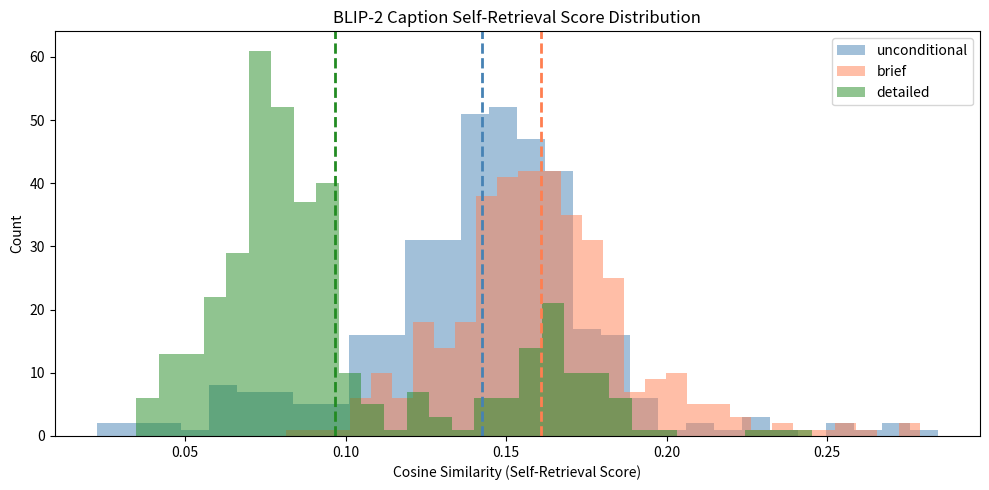

Saved: data/72_blip2_self_retrieval_distribution.png


In [15]:
# Self-Retrieval Score の分布（3モード比較）
fig, ax = plt.subplots(figsize=(10, 5))

colors = ['steelblue', 'coral', 'forestgreen']
for i, mode in enumerate(prompts):
    ax.hist(self_retrieval[mode], bins=30, alpha=0.5, label=mode, color=colors[i])
    ax.axvline(self_retrieval[mode].mean(), color=colors[i], linestyle='--', linewidth=2)

ax.set_xlabel('Cosine Similarity (Self-Retrieval Score)')
ax.set_ylabel('Count')
ax.set_title('BLIP-2 Caption Self-Retrieval Score Distribution')
ax.legend()

plt.tight_layout()
plt.savefig('../data/72_blip2_self_retrieval_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: data/72_blip2_self_retrieval_distribution.png")

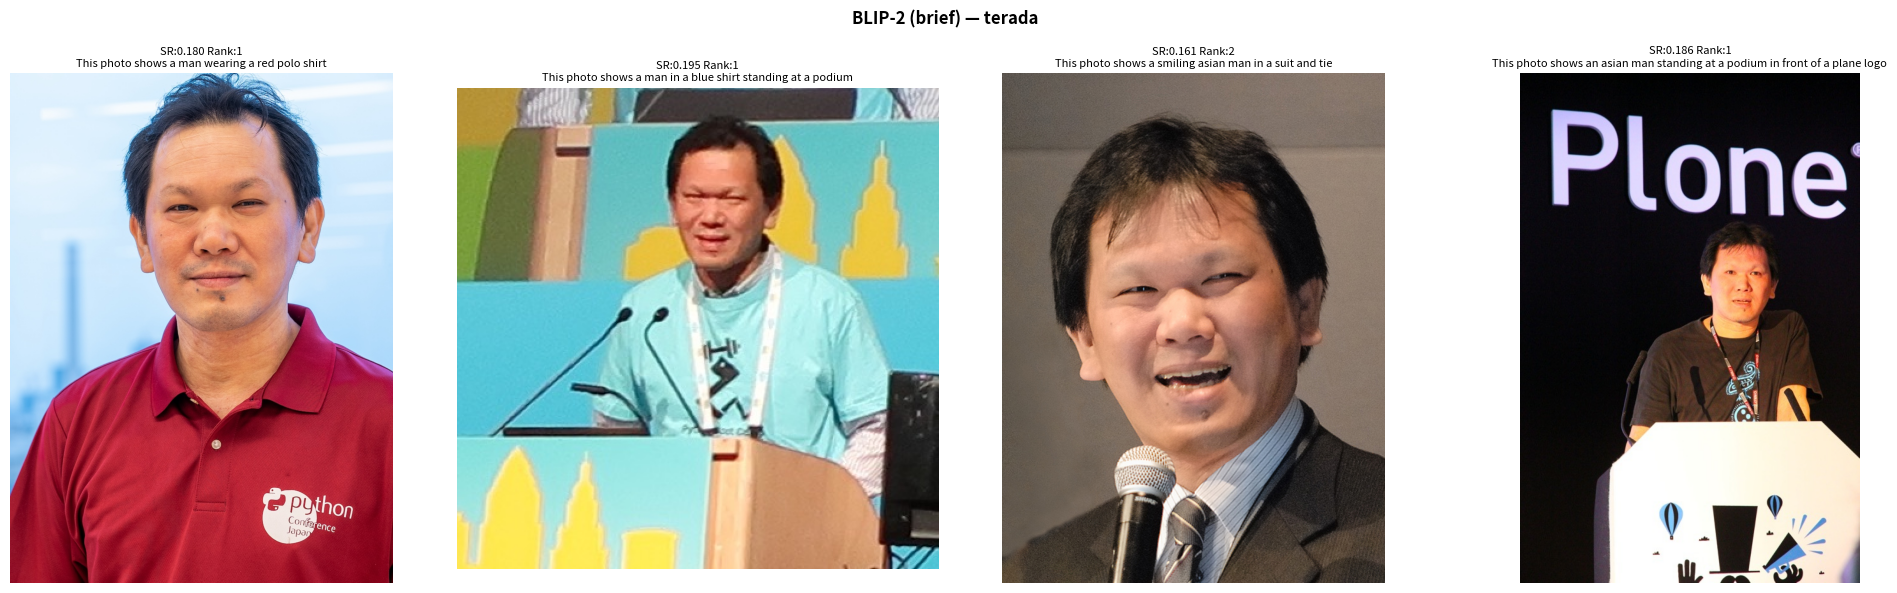

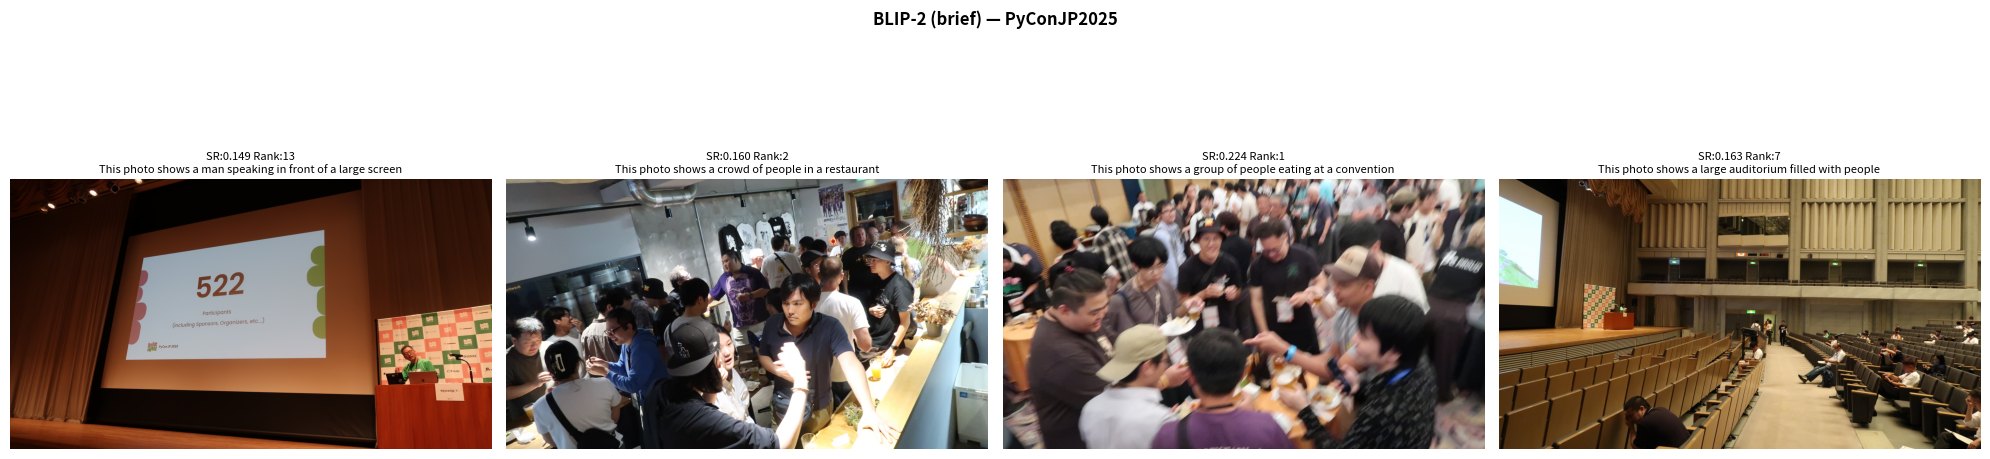

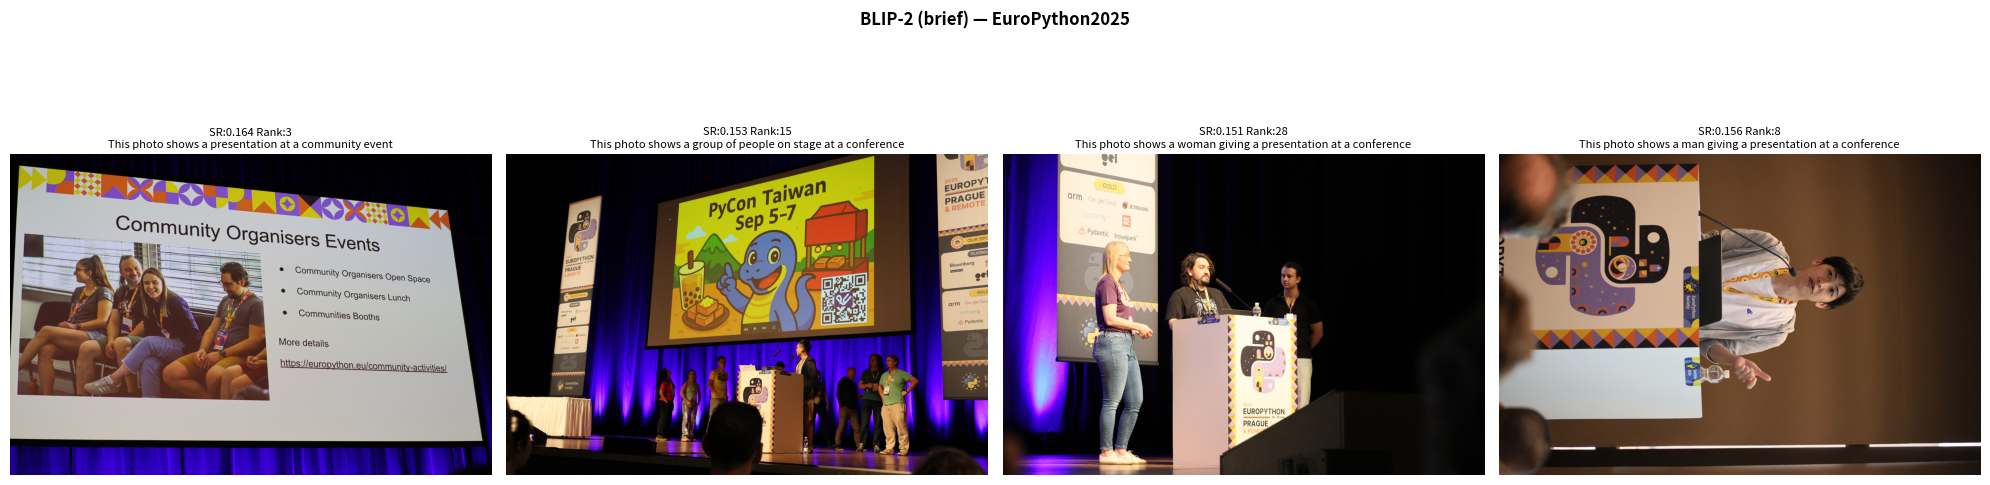

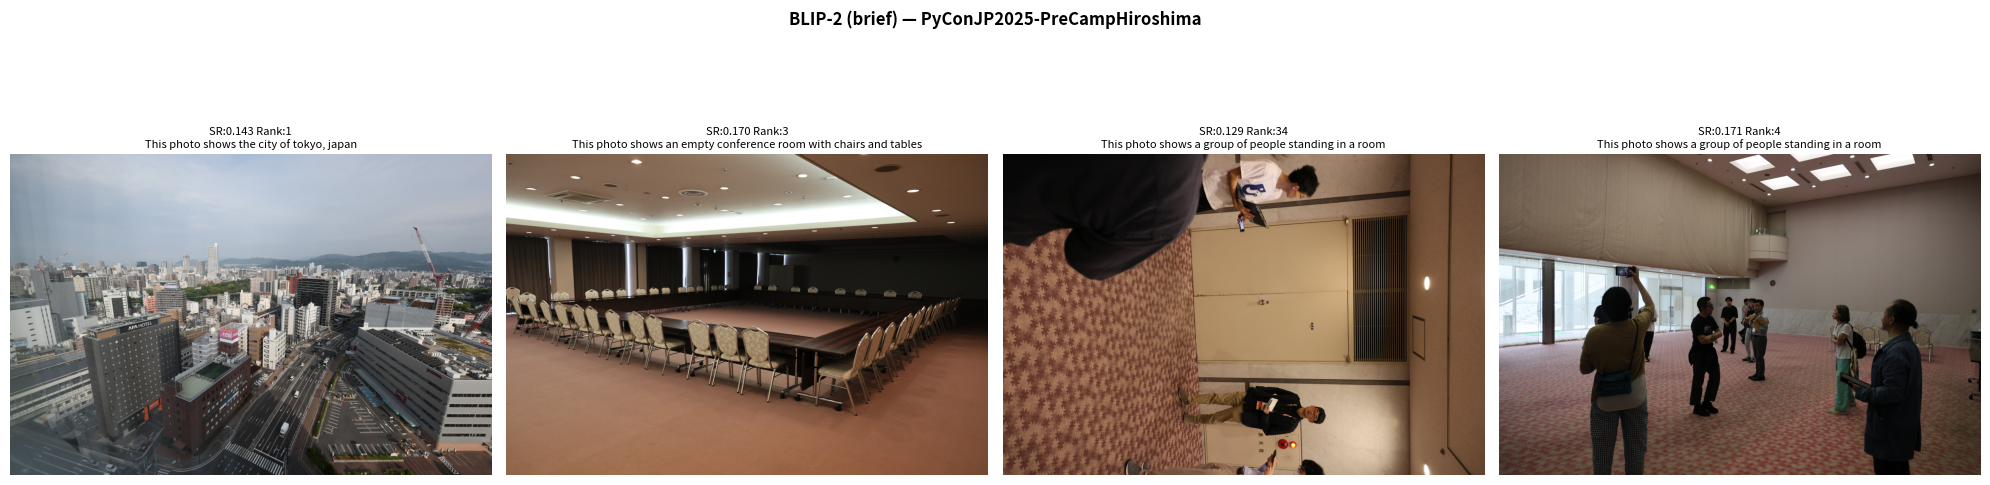

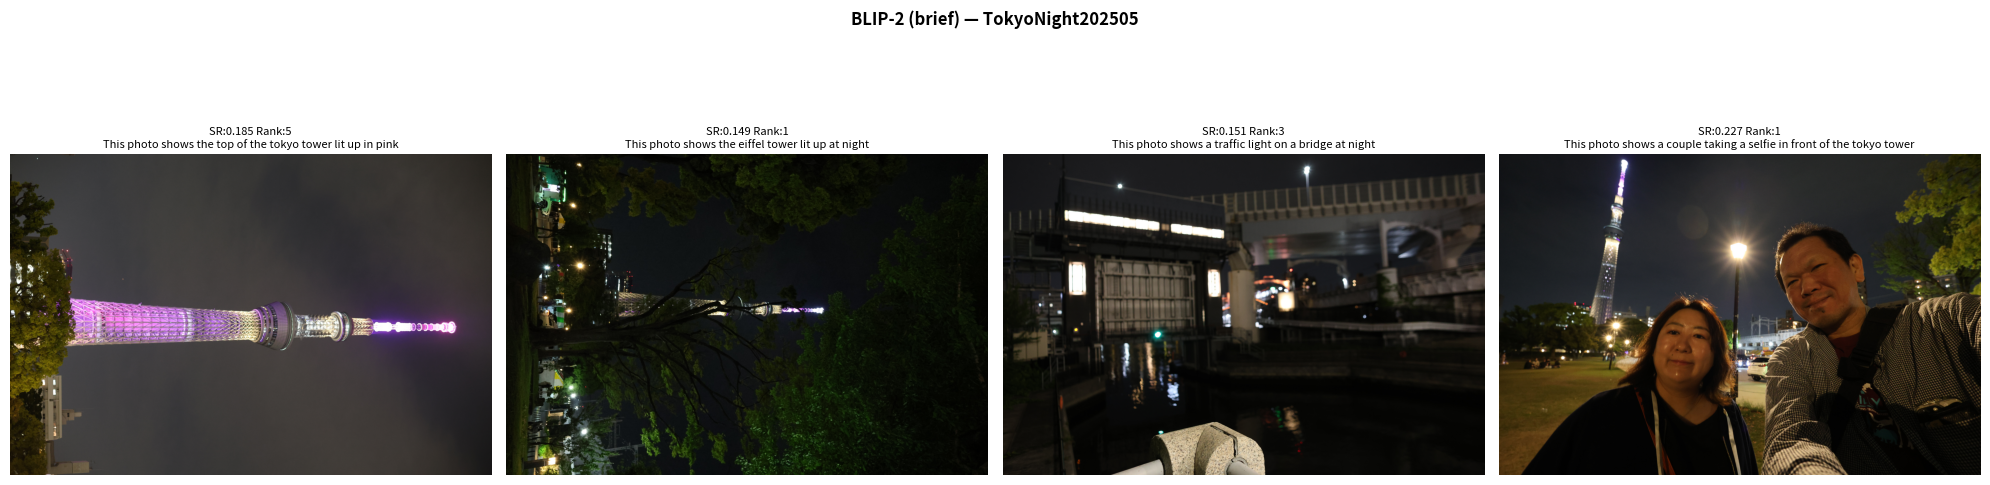

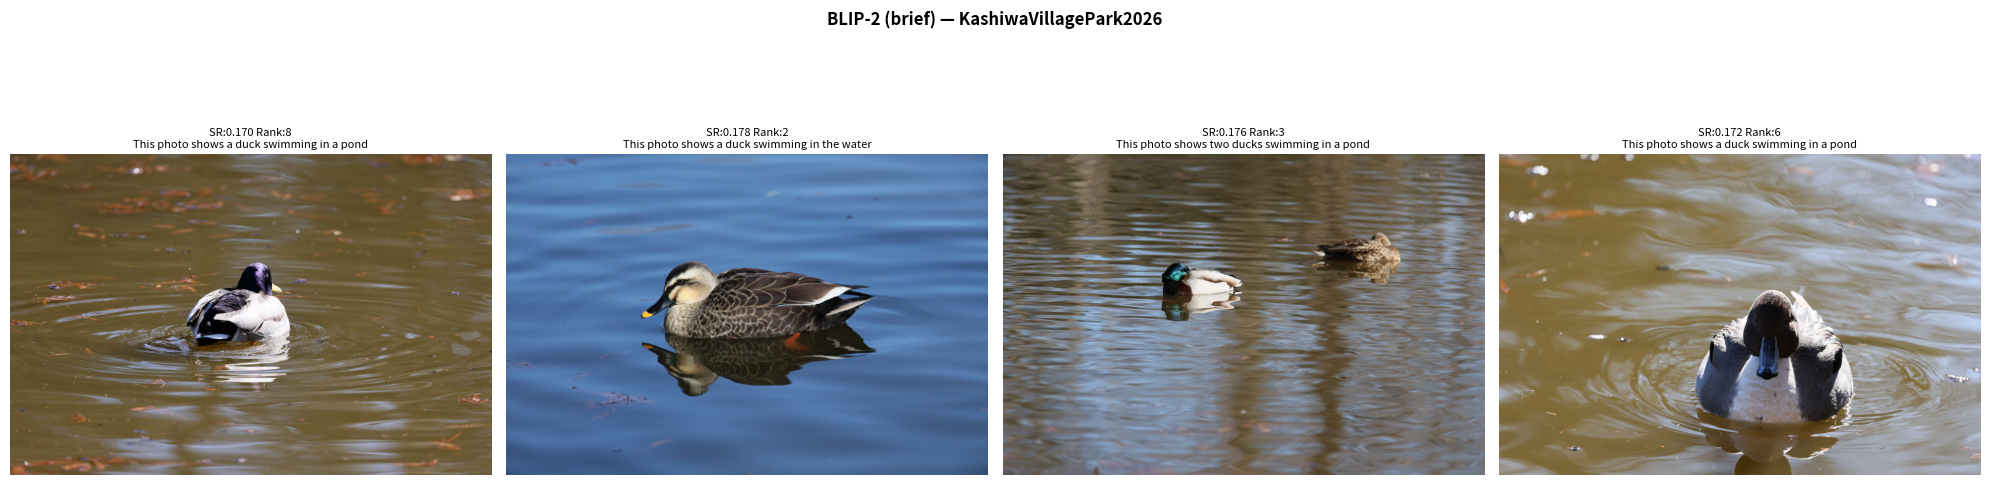

In [16]:
# 画像とキャプションの視覚的確認
for cat in catalog_df['category'].unique():
    cat_indices = catalog_df[catalog_df['category'] == cat].index.tolist()[:4]
    
    fig, axes = plt.subplots(1, len(cat_indices), figsize=(5 * len(cat_indices), 6))
    if len(cat_indices) == 1:
        axes = [axes]
    
    for i, idx in enumerate(cat_indices):
        row = catalog_df.iloc[idx]
        try:
            img = Image.open(row['file_path'])
            axes[i].imshow(img)
        except Exception:
            axes[i].text(0.5, 0.5, 'Image not found', ha='center', va='center')
        
        caption = all_captions[best_mode][idx]
        score = self_retrieval[best_mode][idx]
        rank_val = ranks[idx]
        
        title = f"SR:{score:.3f} Rank:{rank_val}\n{caption[:80]}"
        axes[i].set_title(title, fontsize=8, wrap=True)
        axes[i].axis('off')
    
    plt.suptitle(f'BLIP-2 ({best_mode}) — {cat}', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()
    print()

## 8. Notebook 71 との比較

In [17]:
# Notebook 71 の結果を読み込み
eval_dir = Path("../data/evaluations")
nb71_files = sorted(eval_dir.glob("71_retrieval_captioning_*.json"))

if nb71_files:
    with open(nb71_files[-1]) as f:
        nb71_data = json.load(f)
    print(f"Loaded NB71 results: {nb71_files[-1].name}")
    
    print("\n" + "=" * 80)
    print("Comparison: Notebook 71 (Retrieval-based) vs Notebook 72 (BLIP-2)")
    print("=" * 80)
    
    blip2_sr_mean = self_retrieval[best_mode].mean()
    blip2_mrr = (1.0 / ranks).mean()
    
    nb71_pool_sr = nb71_data['methods']['pool_based']['self_retrieval_en_mean']
    nb71_tag_sr = nb71_data['methods']['tag_based']['self_retrieval_en_mean']
    nb71_mrr = nb71_data['retrieval_rank']['en']['mrr']
    
    print(f"\n{'Method':<30} {'Self-Retrieval':>15} {'Retrieval MRR':>15}")
    print("-" * 62)
    print(f"{'NB71 Tag-based (EN)':<30} {nb71_tag_sr:>15.4f} {'—':>15}")
    print(f"{'NB71 Pool-based (EN)':<30} {nb71_pool_sr:>15.4f} {nb71_mrr:>15.4f}")
    print(f"{'NB72 BLIP-2 (' + best_mode + ')':<30} {blip2_sr_mean:>15.4f} {blip2_mrr:>15.4f}")
    print(f"{'Improvement vs Pool':<30} {blip2_sr_mean - nb71_pool_sr:>+15.4f} {blip2_mrr - nb71_mrr:>+15.4f}")
else:
    print("NB71 results not found. Run notebook 71 first for comparison.")

Loaded NB71 results: 71_retrieval_captioning_2026-02-19.json

Comparison: Notebook 71 (Retrieval-based) vs Notebook 72 (BLIP-2)

Method                          Self-Retrieval   Retrieval MRR
--------------------------------------------------------------
NB71 Tag-based (EN)                     0.1268               —
NB71 Pool-based (EN)                    0.1070          0.1102
NB72 BLIP-2 (brief)                     0.1610          0.4352
Improvement vs Pool                    +0.0540         +0.3250


## 9. DuckDB にキャプションを保存

In [18]:
# image_captions テーブルの作成と保存
conn = duckdb.connect(str(DB_PATH))

conn.execute("""
    CREATE TABLE IF NOT EXISTS image_captions (
        image_id VARCHAR,
        model_name VARCHAR,
        caption_en TEXT,
        caption_ja TEXT,
        prompt_template VARCHAR,
        timestamp TIMESTAMP DEFAULT CURRENT_TIMESTAMP,
        PRIMARY KEY (image_id, model_name, prompt_template)
    )
""")

# 最良モードのキャプションを保存
conn.execute("DELETE FROM image_captions WHERE model_name = ?", [BLIP2_MODEL])

for idx in range(len(catalog_df)):
    image_id = catalog_df.iloc[idx]['id']
    caption_en = all_captions[best_mode][idx]
    
    conn.execute("""
        INSERT INTO image_captions (image_id, model_name, caption_en, caption_ja, prompt_template)
        VALUES (?, ?, ?, NULL, ?)
    """, [image_id, BLIP2_MODEL, caption_en, best_mode])

conn.commit()

count = conn.execute(
    "SELECT COUNT(*) FROM image_captions WHERE model_name = ?", [BLIP2_MODEL]
).fetchone()[0]
print(f"Stored {count} captions for model '{BLIP2_MODEL}'")

conn.close()

Stored 378 captions for model 'Salesforce/blip2-opt-2.7b'


## 10. 結果の保存

In [19]:
output_data = {
    "notebook": "72-blip2-captioning",
    "model_name": BLIP2_MODEL,
    "eval_model": SIGLIP2_MODEL,
    "timestamp": datetime.now().isoformat(),
    "total_images": len(catalog_df),
    "best_mode": best_mode,
    "self_retrieval": {
        mode: {
            "mean": float(self_retrieval[mode].mean()),
            "std": float(self_retrieval[mode].std()),
            "min": float(self_retrieval[mode].min()),
            "max": float(self_retrieval[mode].max()),
        }
        for mode in prompts
    },
    "retrieval_rank": {
        "mode": best_mode,
        "mean_rank": float(ranks.mean()),
        "median_rank": float(np.median(ranks)),
        "rank_at_1_ratio": float((ranks == 1).mean()),
        "rank_le_5_ratio": float((ranks <= 5).mean()),
        "rank_le_10_ratio": float((ranks <= 10).mean()),
        "mrr": float((1.0 / ranks).mean()),
    },
    "caption_stats": {
        mode: {
            "mean_word_count": float(np.mean([len(c.split()) for c in all_captions[mode]])),
            "unique_ratio": len(set(all_captions[mode])) / len(all_captions[mode]),
        }
        for mode in prompts
    },
    "processing_time_seconds": elapsed,
    "speed_captions_per_sec": len(catalog_df) * len(prompts) / elapsed,
}

output_path = Path("../data/evaluations") / f"72_blip2_captioning_{datetime.now().strftime('%Y-%m-%d')}.json"
output_path.parent.mkdir(parents=True, exist_ok=True)

with open(output_path, "w") as f:
    json.dump(output_data, f, indent=2, ensure_ascii=False)

print(f"Results saved to: {output_path}")

Results saved to: ../data/evaluations/72_blip2_captioning_2026-02-19.json


## 11. GPU メモリのクリーンアップ

In [20]:
del embedder

if torch.cuda.is_available():
    torch.cuda.empty_cache()
    print("GPU memory cleared.")

GPU memory cleared.


## まとめ・評価・考察

BLIP-2 (`Salesforce/blip2-opt-2.7b`) で画像キャプションを生成し、
Notebook 71 の擬似キャプション（対照学習モデルによる近似）と比較した。

### 実験結果

| 手法 | Self-Retrieval Score | Retrieval MRR | Rank@1 | 備考 |
|------|:---:|:---:|:---:|:---:|
| NB71 Tag-based (EN) | 0.1268 | — | — | 粗いタグの組み合わせ |
| NB71 Pool-based (EN) | 0.1070 | 0.1102 | 3.7% | 候補プールからの選択 |
| **NB72 BLIP-2 (brief)** | **0.1610** | **0.4352** | **27.2%** | 自然文の生成 |
| NB72 BLIP-2 (unconditional) | 0.1426 | — | — | プロンプトなし |
| NB72 BLIP-2 (detailed) | 0.0967 | — | — | 詳細プロンプト |

### プロンプト別分析

- **brief** (SR 0.161) が最良。"This photo shows" の短い導入が適度にキャプションの方向を制約する。
- **unconditional** (SR 0.143) も良好。自由生成でも BLIP-2 は適切な記述を生成。
- **detailed** (SR 0.097) は最低。"Describe this image in detail:" プロンプトは OPT-2.7B には重すぎ、空出力やハルシネーション（URL生成等）が発生。unique率 29.9% と極めて低い。

### カテゴリ別分析

- **terada**（ポートレート）: MRR 0.825、Rank@1 7/10 と最高。人物の外見（服の色、姿勢等）は高い識別性を持つ。
- **PyConJP2025-PreCampHiroshima**: MRR 0.556 と良好。室内/屋外の多様性がキャプションの個別性に寄与。
- **EuroPython2025**: MRR 0.390 と相対的に低い。類似のカンファレンスシーンが多く、「a group of people on stage」等の汎用的キャプションが重複。
- **KashiwaVillagePark2026**: SR 0.162 と高いが MRR 0.367。自然風景は記述しやすいが、個別の画像特定が難しい。

### NB71 との比較

生成モデル（BLIP-2）は擬似キャプション（対照学習ベースの近似）を大幅に上回った:
- Self-Retrieval Score: **+0.054**（0.107 → 0.161、50%向上）
- Retrieval MRR: **+0.325**（0.110 → 0.435、3倍以上）
- Rank@1: **+23.5pt**（3.7% → 27.2%）

この結果は、画像検索の精度向上にキャプション生成モデルが不可欠であることを示す。

### 考察

1. **BLIP-2 の強み**
   - 軽量（~6GB VRAM）ながら自然で流暢な英語キャプションを生成。
   - 処理速度 2.6 captions/sec と実用的。
   - Q-Former による効率的な画像-テキストブリッジング。

2. **BLIP-2 の制約**
   - **英語のみ**: OPT バックボーンの制約で日本語キャプションは不可。
   - **ドメイン知識の欠如**: 「Pythonカンファレンス」を「presentation」としか記述できない。
   - **detailed モードの品質問題**: OPT-2.7B の限界で、長文生成時にハルシネーションが発生。
   - **unique率の低さ**: brief モードでも 63.5%。類似画像に類似キャプションが割り当てられる。

3. **次のステップ**
   - Notebook 73: Florence-2 でマルチタスク評価（※ transformers 5.x 非互換で SKIP）
   - Notebook 74: Qwen2.5-VL で日本語キャプション生成 → 多言語対応の本格評価